# 05 - Model topology: persistence diagrams per layer and round

Numbers come ONLY from logs/topo.jsonl and artifacts/topo caches (E1: structured JSON, never markdown parsing). The sensor scans fixed probe sentences extracted from data_clean EXCLUDING the frozen holdout (H3 hygiene).

In [1]:
# PROMETHEUS-V2 setup cell — run FIRST. On Colab with GPU desired:
# Runtime > Change runtime type > GPU, then run this.
import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/REPLACE-USER/PROMETHEUS-NS.git"  # <- edit

if IN_COLAB:
    if not Path("/content/PROMETHEUS-NS/.git").exists():
        subprocess.run(["git", "clone", REPO_URL, "/content/PROMETHEUS-NS"],
                       check=True)
    os.chdir("/content/PROMETHEUS-NS")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-r", "requirements.txt"], check=True)
    print("Colab setup complete.")
else:
    try:
        import torch, ripser, scipy, networkx  # noqa: F401
        print("Local environment OK.")
    except ImportError as exc:
        raise SystemExit(f"Missing dependency ({exc}). Run `make setup`.")


Local environment OK.


In [2]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
while not (REPO / "config.yaml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
os_cwd = Path.cwd()

FIG_DIR = REPO / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_jsonl(path):
    path = Path(path)
    if not path.is_file():
        return []
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows


def save_figure(fig, name):
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=130, bbox_inches="tight")
    print(f"figure -> {out}")


TOPO = load_jsonl(REPO / "logs" / "topo.jsonl")
DECISIONS = load_jsonl(REPO / "logs" / "promotion_decisions.jsonl")
print(f"topo.jsonl rows: {len(TOPO)} | decisions: {len(DECISIONS)}")


topo.jsonl rows: 6 | decisions: 6


## betti0@eps per round with the running minimum (D3 baseline)

The R2 collapse floor compares against the RUNNING MINIMUM of betti0@eps: a legitimately improving structure never creates a false floor.

In [3]:
rows = [{"round": r["round_id"], "stress": r.get("stress_mode"),
         "betti0": r["betti0_eps"],
         "baseline": r.get("establish_baseline", False)}
        for r in TOPO if isinstance(r.get("betti0_eps"), (int, float))]
betti = pd.DataFrame(rows)
if betti.empty:
    raise SystemExit("no topological measurements yet: run the V2 rounds")
betti["running_min"] = betti["betti0"].cummin()
print(betti.to_string(index=False))

 round              stress  betti0  baseline  running_min
     1                 NaN      72      True           72
     2                 NaN      81     False           72
     3                 NaN     115     False           72
     4           dup_flood     125     False           72
     5 contradiction_flood     109     False           72
     6            lr_spike       4     False            4


figure -> /home/z/my-project/prometheus-ns/docs/figures/nb5_betti0_per_round.png


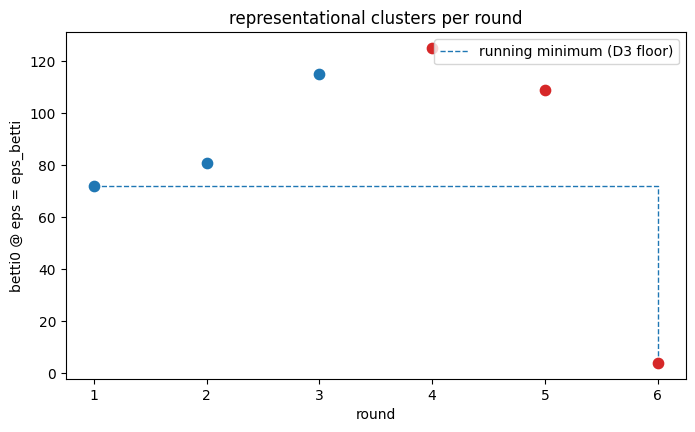

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
kinds = betti["stress"].fillna("normal")
colors = {"normal": "#1f77b4"}
for i, (idx, row) in enumerate(betti.iterrows()):
    color = "tab:red" if isinstance(row["stress"], str) else "tab:blue"
    ax.scatter(row["round"], row["betti0"], color=color, zorder=3, s=55)
ax.step(betti["round"], betti["running_min"], where="post",
        ls="--", lw=1.0, label="running minimum (D3 floor)")
ax.set_xlabel("round"); ax.set_ylabel("betti0 @ eps = eps_betti")
ax.set_title("representational clusters per round")
ax.legend(); save_figure(fig, "nb5_betti0_per_round"); plt.show()

## Self-noise distribution of the sensor (Fase 1-V2, risk A3)

The churn threshold only means something above the subsampling noise floor: 5 seeds, pairwise self-bottleneck per layer.

figure -> /home/z/my-project/prometheus-ns/docs/figures/nb5_self_noise.png


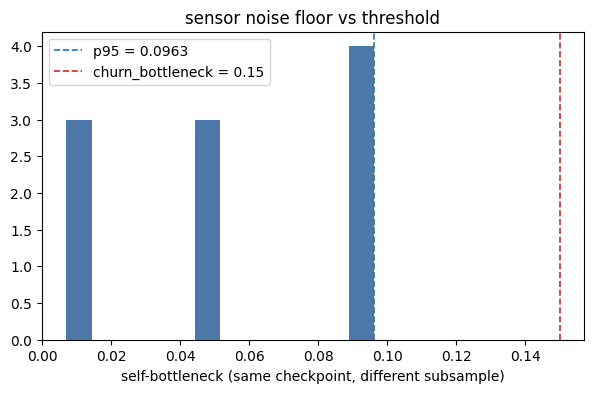

In [5]:
sn_path = REPO / "artifacts" / "topo" / "self_noise.json"
if not sn_path.is_file():
    print("self_noise.json missing: the sensor is NOT calibrated yet "
          "(Fase 1-V2 verification on the real champion)")
else:
    sn = json.loads(sn_path.read_text(encoding="utf-8"))
    values = [sn["layers"][layer]["pairwise"][i][j]
              for layer in sn["layers"]
              for i in range(len(sn["seeds"]))
              for j in range(i + 1, len(sn["seeds"]))]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(values, bins=12, color="#4c78a8")
    ax.axvline(sn["p95_overall"], ls="--", lw=1.2,
               label=f"p95 = {sn['p95_overall']:.4f}")
    import yaml
    cfg = yaml.safe_load((REPO / "config.yaml").read_text(encoding="utf-8"))
    thr = cfg["topo"]["churn_bottleneck"]
    ax.axvline(thr, color="tab:red", ls="--", lw=1.2,
               label=f"churn_bottleneck = {thr}")
    ax.set_xlabel("self-bottleneck (same checkpoint, different subsample)")
    ax.set_title("sensor noise floor vs threshold")
    ax.legend(); save_figure(fig, "nb5_self_noise"); plt.show()

## Interpretation and limits

- The topological sensor DESCRIBES geometry; it does not cause quality (descriptive, not causal).
- One model, one geometry policy, one seed: comparisons across rounds with an identical pipeline only.